# Determine Movie Genre by Neighboring Movies

Using the k-nearest neighbors method, use the top-k most similar movies to a target film to predict the target movie's genre.

Use Jaccard similarity based on actors in each movie to rank movies and select the top-k most similar movies.

In [2]:
import json

import pandas as pd
import numpy as np

from scipy.sparse import lil_matrix

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer


In [3]:
actor_name_map = {}
movie_actor_map = {}
actor_genre_map = {}


with open("imdb_movies_2000to2022.prolific.json", "r") as in_file:
    for line in in_file:
        
        # Read the movie on this line and parse its json
        this_movie = json.loads(line)
        
        # Skip movies with no ratings
        if len(this_movie["rating"]) == 0:
            continue
                    
        # Add all actors to the id->name map
        for actor_id,actor_name in this_movie['actors']:
            actor_name_map[actor_id] = actor_name
            
        # For each actor, add this movie's genres to that actor's list
        for actor_id,actor_name in this_movie['actors']:
            this_actors_genres = actor_genre_map.get(actor_id, {})
            
            # Increment the count of genres for this actor
            for g in this_movie["genres"]:
                this_actors_genres[g] = this_actors_genres.get(g, 0) + 1
                
            # Update the map
            actor_genre_map[actor_id] = this_actors_genres
            
        # Finished with this film
        movie_actor_map[this_movie["imdb_id"]] = ({
            "movie": this_movie["title"],
            "actors": set([item[0] for item in this_movie['actors']]),
            "genres": this_movie["genres"],
            "rating": this_movie["rating"]["avg"]
        })


       

In [ ]:


# Prep data
movie_ids = list(movie_actor_map.keys())
genres = [movie_actor_map[movie_id]['genres'] for movie_id in movie_ids]
actors = [list(movie_actor_map[movie_id]['actors']) for movie_id in movie_ids]

# Convert genres and actors into binary features
mlb_genres = MultiLabelBinarizer()
mlb_actors = MultiLabelBinarizer()

X = mlb_actors.fit_transform(actors)
y = mlb_genres.fit_transform(genres)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



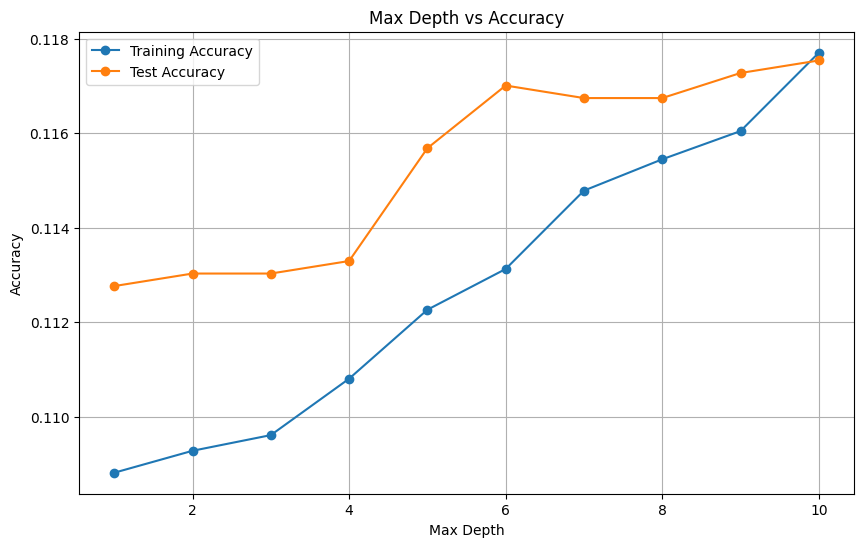

In [ ]:
#valuate accuracy for different max_depth values
train_accuracies = []
test_accuracies = []

for max_depth in range(1, 11):
    # initialize and train the classifier
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # oredict on training and test sets
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    #  accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# relationship between max_depth and accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, 11), test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Max Depth vs Accuracy')
plt.legend()
plt.grid()
plt.show()